# CIFAR-10 CNN: TinyMML vs Keras

Compare equivalent convolutional networks implemented with TinyMML and Keras on natural-image classification.


In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

PROFILE_CONFIGS = {
    "reduced": {
        "train_samples": 1_000,
        "test_samples": 250,
        "epochs": 3,
        "batch_size": 32,
        "inference_repeats": 5,
    },
    "full": {
        "train_samples": 50_000,
        "test_samples": 10_000,
        "epochs": 10,
        "batch_size": 32,
        "inference_repeats": 10,
    },
}

PROFILE = "reduced"  # Choose "reduced" or "full".
if PROFILE not in PROFILE_CONFIGS:
    raise ValueError("PROFILE must be 'reduced' or 'full'")

CONFIG = {
    **PROFILE_CONFIGS[PROFILE],
    "seed": 42,
    "learning_rate": 1e-3,
}

In [21]:
from importlib.metadata import version
from io import BytesIO
from pathlib import Path
from time import perf_counter
import platform
import sys

ROOT = Path.cwd()
if not (ROOT / "tinymodel").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pyarrow.parquet as pq
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras

tf.config.set_visible_devices([], "GPU")

import tinytensor as tt
import tinymodel as tm

np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
keras.utils.set_random_seed(CONFIG["seed"])
assert tf.config.get_visible_devices("GPU") == []

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

environment = {
    "profile": PROFILE,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "logical CPUs": os.cpu_count(),
    "CPU threading": "runtime automatic",
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "TensorFlow": tf.__version__,
    "Keras": keras.__version__,
    "scikit-learn": version("scikit-learn"),
    "TinyTensor CUDA": tt.cuda_available(),
}

display(environment)
display(CONFIG)


{'profile': 'full',
 'platform': 'macOS-26.5.1-arm64-arm-64bit-Mach-O',
 'machine': 'arm64',
 'logical CPUs': 8,
 'CPU threading': 'runtime automatic',
 'Python': '3.13.14',
 'NumPy': '2.4.3',
 'TensorFlow': '2.21.0',
 'Keras': '3.15.0',
 'scikit-learn': '1.9.0',
 'TinyTensor CUDA': False}

{'train_samples': 50000,
 'test_samples': 10000,
 'epochs': 10,
 'batch_size': 32,
 'inference_repeats': 10,
 'seed': 42,
 'learning_rate': 0.001}

## Dataset and experiment

CIFAR-10 contains 60,000 color images. Each image is `32 × 32 × 3` pixels and belongs to one of ten classes, with 50,000 official training images and 10,000 test images.

This notebook selects a class-balanced profile, scales pixels to `[0, 1]`, converts images to TinyMML's `NCHW` and Keras's `NHWC` layouts, trains matched two-block CNNs, then compares classification quality and CPU performance.


In [ ]:
def stratified_subset(labels, count, seed):
    indices = np.arange(len(labels))
    if count == len(labels):
        return indices

    selected, _ = train_test_split(
        indices,
        train_size=count,
        stratify=labels,
        random_state=seed,
    )
    return np.asarray(selected)


def cached_huggingface_cifar(split):
    files = {
        "train": (
            "train-00000-of-00001.parquet",
            "8428b53a88a11ac374111006708df51469e315a22ac6d66470afd9c78d2ae883",
        ),
        "test": (
            "test-00000-of-00001.parquet",
            "841389e6f2d64f28bf17310e430aebac20ec3ba611a3c5e231dc93c645ce84de",
        ),
    }
    filename, sha256 = files[split]
    origin = (
        "https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/"
        f"plain_text/{filename}?download=true"
    )
    return Path(keras.utils.get_file(
        fname=filename,
        origin=origin,
        file_hash=sha256,
        cache_dir=str(ROOT / "data"),
        cache_subdir="cifar10",
    ))


def load_cifar_subset(path, sample_count, seed):
    labels = pq.read_table(path, columns=["label"])["label"].to_numpy()
    indices = stratified_subset(labels, sample_count, seed)
    parquet = pq.ParquetFile(path)
    row_group_size = parquet.metadata.row_group(0).num_rows
    images = np.empty((sample_count, 32, 32, 3), dtype=np.uint8)
    groups = indices // row_group_size

    for row_group in np.unique(groups):
        output_positions = np.flatnonzero(groups == row_group)
        encoded = parquet.read_row_group(
            int(row_group),
            columns=["img"],
        )["img"].to_pylist()
        for output_position in output_positions:
            local_row = int(indices[output_position] % row_group_size)
            image_bytes = encoded[local_row]["bytes"]
            image = Image.open(BytesIO(image_bytes)).convert("RGB")
            images[output_position] = np.asarray(image)

    return images, labels[indices].astype(np.int64)


def one_hot(labels, classes=10):
    return np.eye(classes, dtype=np.float32)[np.asarray(labels)]


def probabilities(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=1, keepdims=True)


def benchmark_inference(predict, samples, repeats):
    predict()
    durations = []
    for _ in range(repeats):
        started = perf_counter()
        predict()
        durations.append(perf_counter() - started)

    median = float(np.median(durations))
    return 1_000 * median, samples / median


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = [
        "| " + " | ".join(str(row[column]) for column in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, divider, *body])

## Load and prepare CIFAR-10

The verified parquet files are cached under the ignored `data/cifar10` directory. Download and decoding time are outside the training benchmark.


In [ ]:
train_path = cached_huggingface_cifar("train")
test_path = cached_huggingface_cifar("test")

x_train_uint8, y_train = load_cifar_subset(
    train_path,
    CONFIG["train_samples"],
    CONFIG["seed"],
)
x_test_uint8, y_test = load_cifar_subset(
    test_path,
    CONFIG["test_samples"],
    CONFIG["seed"] + 1,
)

x_train_keras = x_train_uint8.astype(np.float32) / 255.0
x_test_keras = x_test_uint8.astype(np.float32) / 255.0
x_train_tiny = np.ascontiguousarray(x_train_keras.transpose(0, 3, 1, 2))
x_test_tiny = np.ascontiguousarray(x_test_keras.transpose(0, 3, 1, 2))
y_train_one_hot = one_hot(y_train)
y_test_one_hot = one_hot(y_test)

print(f"Selected TinyMML NCHW: {x_train_tiny.shape} / {x_test_tiny.shape}")
print(f"Selected Keras NHWC: {x_train_keras.shape} / {x_test_keras.shape}")
print(
    "Pixel mean/std after scaling: "
    f"{x_train_keras.mean():.3f} / {x_train_keras.std():.3f}"
)
print("Train class counts:", np.bincount(y_train, minlength=10).tolist())

Selected TinyMML NCHW: (50000, 3, 32, 32) / (10000, 3, 32, 32)
Selected Keras NHWC: (50000, 32, 32, 3) / (10000, 32, 32, 3)
Pixel mean/std after scaling: 0.473 / 0.252
Train class counts: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]


## Explore the selected data

The plots show one image from each class, the selected class balance, and the normalized pixel distribution.


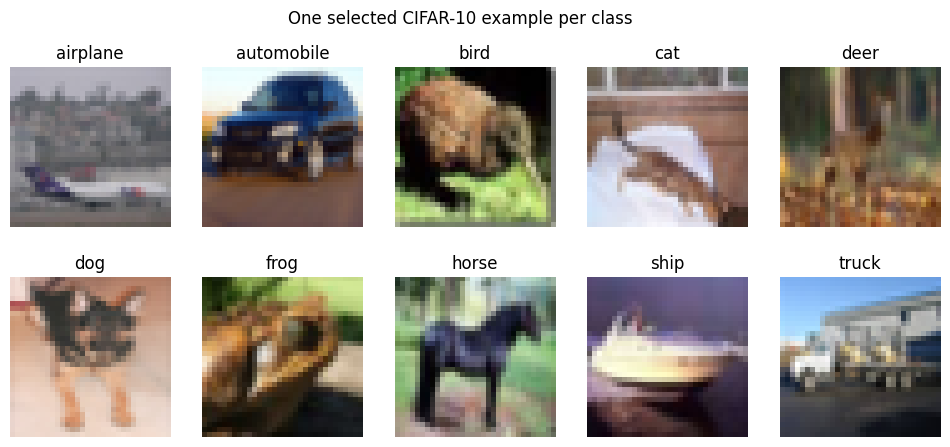

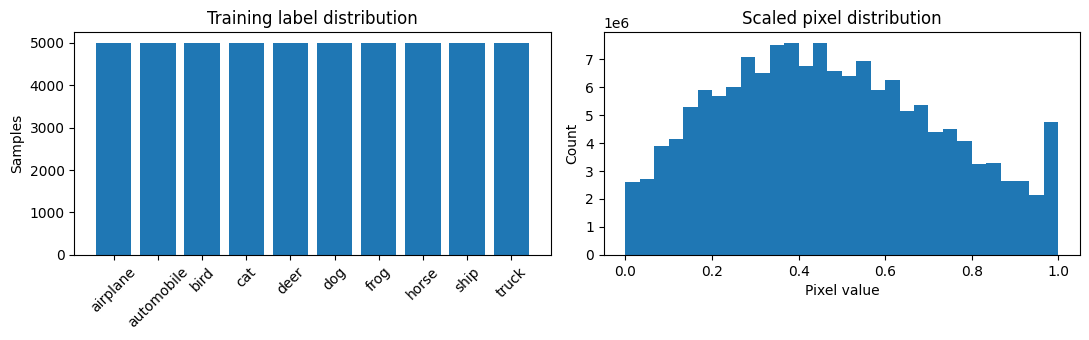

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for label, axis in enumerate(axes.flat):
    image_index = np.flatnonzero(y_train == label)[0]
    axis.imshow(x_train_uint8[image_index])
    axis.set_title(CLASS_NAMES[label])
    axis.axis("off")

plt.suptitle("One selected CIFAR-10 example per class")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(CLASS_NAMES, np.bincount(y_train, minlength=10))
axes[0].tick_params(axis="x", rotation=45)
axes[0].set(
    title="Training label distribution",
    ylabel="Samples",
)
axes[1].hist(x_train_keras.ravel(), bins=30)
axes[1].set(
    title="Scaled pixel distribution",
    xlabel="Pixel value",
    ylabel="Count",
)
plt.tight_layout()
plt.show()

## Matched CNNs

Both models use two stride-2 convolution blocks, dropout rates `0.1/0.2/0.3`, a 64-unit dense head, He initialization, Adam at `1e-3`, and logits categorical cross-entropy.


In [ ]:
tiny_model = tm.Model([
    tm.Conv2D(16, 3, stride=2, padding=1, init="he"),
    tm.ReLU(),
    tm.Dropout(0.1),
    tm.Conv2D(32, 3, stride=2, padding=1, init="he"),
    tm.ReLU(),
    tm.Dropout(0.2),
    tm.Flatten(),
    tm.Linear(64, init="he"),
    tm.ReLU(),
    tm.Dropout(0.3),
    tm.Linear(10),
])
tiny_model.build(list(x_train_tiny.shape))
tiny_optimizer = tm.Adam(
    tiny_model.parameters(),
    lr=CONFIG["learning_rate"],
)
tiny_loss = tm.CrossEntropyLoss()

keras_model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(
        16,
        3,
        strides=2,
        padding="same",
        kernel_initializer="he_normal",
    ),
    keras.layers.ReLU(),
    keras.layers.Dropout(0.1),
    keras.layers.Conv2D(
        32,
        3,
        strides=2,
        padding="same",
        kernel_initializer="he_normal",
    ),
    keras.layers.ReLU(),
    keras.layers.Dropout(0.2),
    keras.layers.Flatten(),
    keras.layers.Dense(64, kernel_initializer="he_normal"),
    keras.layers.ReLU(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10),
])
keras_model.compile(
    optimizer=keras.optimizers.Adam(CONFIG["learning_rate"]),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

model_info = [
    {
        "library": "TinyMML",
        "parameters": sum(parameter.size() for parameter in tiny_model.parameters()),
        "steps/epoch": int(
            np.ceil(len(x_train_tiny) / CONFIG["batch_size"])
        ),
    },
    {
        "library": "Keras",
        "parameters": keras_model.count_params(),
        "steps/epoch": int(
            np.ceil(len(x_train_keras) / CONFIG["batch_size"])
        ),
    },
]
display(Markdown(markdown_table(
    model_info,
    ["library", "parameters", "steps/epoch"],
)))

| library | parameters | steps/epoch |
| --- | --- | --- |
| TinyMML | 136874 | 1563 |
| Keras | 136874 | 1563 |

## Train and compare


Timings are CPU-only and hardware-dependent. Thread counts are left unset so OpenMP and TensorFlow can choose the available parallelism. Keras uses highly optimized TensorFlow kernels; TinyMML prioritizes a readable educational implementation, so equal runtime is not expected.


In [26]:
started = perf_counter()
tiny_history = tiny_model.fit(
    x_train_tiny,
    y_train_one_hot,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    optimizer=tiny_optimizer,
    loss_fn=tiny_loss,
    metric="accuracy",
    verbose=False,
)
tiny_train_seconds = perf_counter() - started

started = perf_counter()
keras_history = keras_model.fit(
    x_train_keras,
    y_train_one_hot,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    verbose=0,
)
keras_train_seconds = perf_counter() - started

tiny_test_loss, tiny_test_accuracy, tiny_logits = tiny_model.evaluate(
    x_test_tiny,
    y_test_one_hot,
    tiny_loss,
    batch_size=CONFIG["batch_size"],
    metric="accuracy",
    return_outputs=True,
)
keras_evaluation = keras_model.evaluate(
    x_test_keras,
    y_test_one_hot,
    batch_size=CONFIG["batch_size"],
    verbose=0,
    return_dict=True,
)
keras_logits = keras_model.predict(
    x_test_keras,
    batch_size=CONFIG["batch_size"],
    verbose=0,
)

tiny_probabilities = probabilities(tiny_logits)
keras_probabilities = probabilities(keras_logits)
tiny_predictions = tiny_probabilities.argmax(axis=1)
keras_predictions = keras_probabilities.argmax(axis=1)

tiny_latency, tiny_throughput = benchmark_inference(
    lambda: tiny_model.predict(
        x_test_tiny,
        batch_size=CONFIG["batch_size"],
    ),
    len(x_test_tiny),
    CONFIG["inference_repeats"],
)
keras_latency, keras_throughput = benchmark_inference(
    lambda: keras_model.predict(
        x_test_keras,
        batch_size=CONFIG["batch_size"],
        verbose=0,
    ),
    len(x_test_keras),
    CONFIG["inference_repeats"],
)

results = [
    {
        "library": "TinyMML",
        "test loss": f"{tiny_test_loss:.4f}",
        "accuracy": f"{tiny_test_accuracy:.3f}",
        "training s": f"{tiny_train_seconds:.2f}",
        "inference ms": f"{tiny_latency:.2f}",
        "samples/s": f"{tiny_throughput:.1f}",
    },
    {
        "library": "Keras",
        "test loss": f"{keras_evaluation['loss']:.4f}",
        "accuracy": f"{accuracy_score(y_test, keras_predictions):.3f}",
        "training s": f"{keras_train_seconds:.2f}",
        "inference ms": f"{keras_latency:.2f}",
        "samples/s": f"{keras_throughput:.1f}",
    },
]
display(Markdown(markdown_table(results, list(results[0]))))

| library | test loss | accuracy | training s | inference ms | samples/s |
| --- | --- | --- | --- | --- | --- |
| TinyMML | 1.0571 | 0.632 | 1610.16 | 5863.46 | 1705.5 |
| Keras | 1.0287 | 0.633 | 53.20 | 323.89 | 30874.4 |

## Diagnostics

Learning curves show optimization progress. Normalized confusion matrices and shared test examples show where each model succeeds or fails.


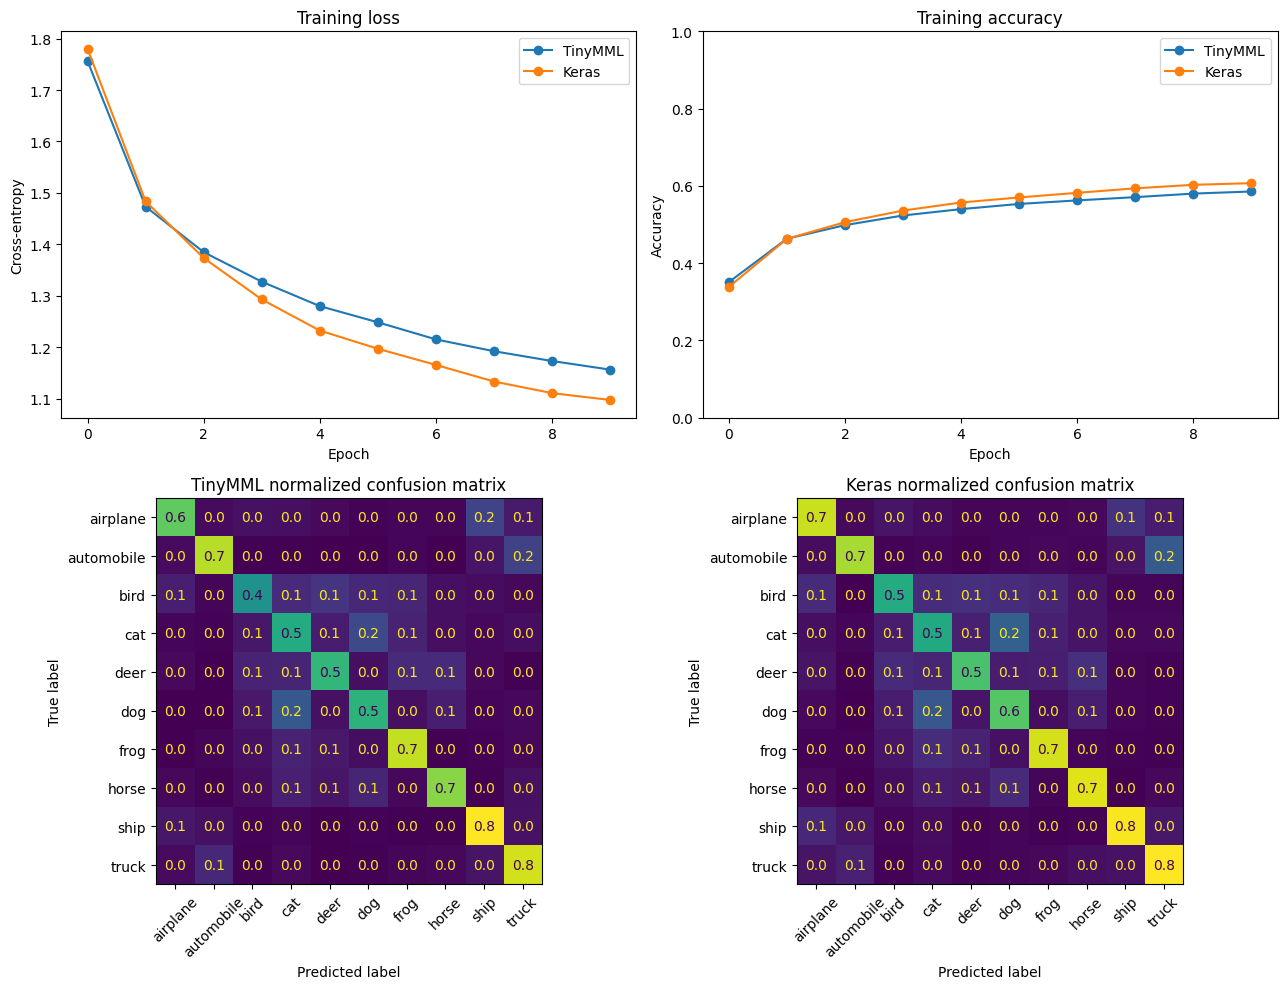

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].plot(tiny_history["loss"], marker="o", label="TinyMML")
axes[0, 0].plot(keras_history.history["loss"], marker="o", label="Keras")
axes[0, 0].set(
    title="Training loss",
    xlabel="Epoch",
    ylabel="Cross-entropy",
)
axes[0, 0].legend()

axes[0, 1].plot(tiny_history["metric"], marker="o", label="TinyMML")
axes[0, 1].plot(
    keras_history.history["accuracy"],
    marker="o",
    label="Keras",
)
axes[0, 1].set(
    title="Training accuracy",
    xlabel="Epoch",
    ylabel="Accuracy",
    ylim=(0, 1),
)
axes[0, 1].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tiny_predictions,
    display_labels=CLASS_NAMES,
    normalize="true",
    values_format=".1f",
    ax=axes[1, 0],
    colorbar=False,
    xticks_rotation=45,
)
axes[1, 0].set_title("TinyMML normalized confusion matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    keras_predictions,
    display_labels=CLASS_NAMES,
    normalize="true",
    values_format=".1f",
    ax=axes[1, 1],
    colorbar=False,
    xticks_rotation=45,
)
axes[1, 1].set_title("Keras normalized confusion matrix")

plt.tight_layout()
plt.show()

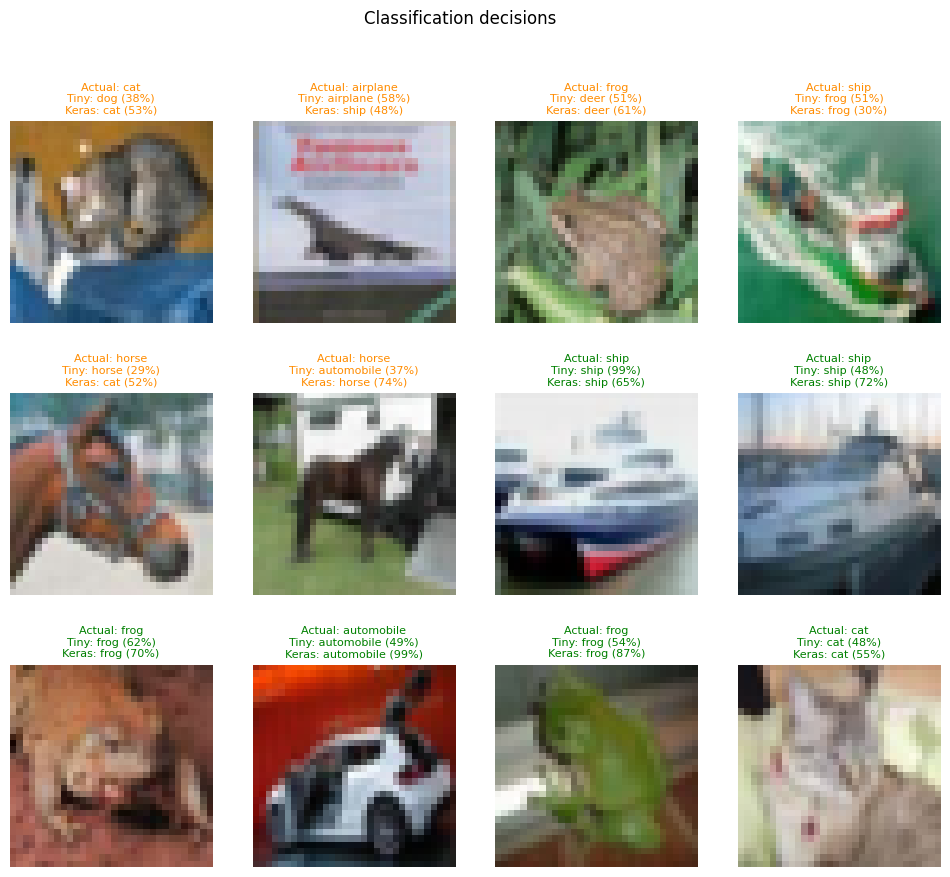

In [28]:
wrong = np.flatnonzero((tiny_predictions != y_test) | (keras_predictions != y_test))[:6]
correct = np.flatnonzero((tiny_predictions == y_test) & (keras_predictions == y_test))[: 12 - len(wrong)]
decision_indices = np.concatenate([wrong, correct])[:12]

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
for axis, index in zip(axes.flat, decision_indices):
    axis.imshow(x_test_uint8[index])
    actual = y_test[index]
    both_correct = (
        tiny_predictions[index] == actual
        and keras_predictions[index] == actual
    )
    title_color = "green" if both_correct else "darkorange"
    axis.set_title(
        f"Actual: {CLASS_NAMES[actual]}\n"
        f"Tiny: {CLASS_NAMES[tiny_predictions[index]]} "
        f"({tiny_probabilities[index].max():.0%})\n"
        f"Keras: {CLASS_NAMES[keras_predictions[index]]} "
        f"({keras_probabilities[index].max():.0%})",
        color=title_color,
        fontsize=8,
    )
    axis.axis("off")

for axis in axes.flat[len(decision_indices):]:
    axis.axis("off")

plt.suptitle("Classification decisions")
plt.show()